In [2]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
github_token = user_secrets.get_secret("github-token")
!git clone https://{github_token}@github.com/manaal-m/acdc-cardiac-mri-segmentation.git
%cd acdc-cardiac-mri-segmentation

Cloning into 'acdc-cardiac-mri-segmentation'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 29 (delta 1), reused 25 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (29/29), 289.71 KiB | 2.66 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/kaggle/working/acdc-cardiac-mri-segmentation


In [3]:
%pip install -q lightning nibabel segmentation-models-pytorch kagglehub torchinfo

import os
import json
import time
import numpy as np
import torch
import pytorch_lightning as pl

from src.model import LitUNet2D
from src.dataset import ACDC2DDataModule
import kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 629.8 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 5.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [4]:
ENCODERS = ["resnet18", "vgg16", "mobilenet_v2", "resnet50"]
SEEDS = [42, 0, 11]
LR = 1e-3
CHECKPOINT_DIR = "/kaggle/input/datasets/manaalmay/acdc-multiseed-checkpoints"

In [5]:
data_path = kagglehub.dataset_download("samdazel/automated-cardiac-diagnosis-challenge-miccai17")
acdc_root = f"{data_path}/database/training"
print("Data ready:", acdc_root)

Data ready: /kaggle/input/datasets/samdazel/automated-cardiac-diagnosis-challenge-miccai17/database/training


In [6]:
import os
import zipfile

FIXED_DIR = "/kaggle/working/fixed_checkpoints"
os.makedirs(FIXED_DIR, exist_ok=True)

for folder in os.listdir(CHECKPOINT_DIR):
    folder_path = os.path.join(CHECKPOINT_DIR, folder)
    archive_path = os.path.join(folder_path, "archive")
    if not os.path.isdir(archive_path):
        continue
    
    output_ckpt = os.path.join(FIXED_DIR, f"{folder}.ckpt")
    
    with zipfile.ZipFile(output_ckpt, 'w', zipfile.ZIP_STORED) as zf:
        for root, dirs, files in os.walk(archive_path):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.join("archive", os.path.relpath(file_path, archive_path))
                zf.write(file_path, arcname)
    
    print(f"Repacked: {output_ckpt}")

print("Done")

Repacked: /kaggle/working/fixed_checkpoints/seed11_resnet50-acdc-epoch08-val_dice0.9113.ckpt
Repacked: /kaggle/working/fixed_checkpoints/seed42_vgg16-acdc-epoch23-val_dice0.9069.ckpt
Repacked: /kaggle/working/fixed_checkpoints/seed42_resnet18-acdc-epoch46-val_dice0.9078.ckpt
Repacked: /kaggle/working/fixed_checkpoints/seed11_vgg16-acdc-epoch26-val_dice0.9150.ckpt
Repacked: /kaggle/working/fixed_checkpoints/seed42_mobilenet_v2-acdc-epoch33-val_dice0.9010.ckpt
Repacked: /kaggle/working/fixed_checkpoints/seed0_resnet50-acdc-epoch25-val_dice0.9029.ckpt
Repacked: /kaggle/working/fixed_checkpoints/seed11_resnet18-acdc-epoch26-val_dice0.9081.ckpt
Repacked: /kaggle/working/fixed_checkpoints/seed0_mobilenet_v2-acdc-epoch28-val_dice0.9020.ckpt
Repacked: /kaggle/working/fixed_checkpoints/seed0_vgg16-acdc-epoch29-val_dice0.9092.ckpt
Repacked: /kaggle/working/fixed_checkpoints/seed11_mobilenet_v2-acdc-epoch32-val_dice0.9108.ckpt
Repacked: /kaggle/working/fixed_checkpoints/seed0_resnet18-acdc-epoch4

In [7]:
import glob

def find_ckpt(checkpoint_dir, seed, encoder):
    pattern = os.path.join(FIXED_DIR, f"seed{seed}_{encoder}-acdc-*.ckpt")
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(f"No checkpoint found for seed{seed}_{encoder}")
    return matches[0]

In [7]:
all_seed_results = {}

for seed in SEEDS:
    pl.seed_everything(seed, workers=True)
    dm = ACDC2DDataModule(acdc_root, batch_size=8, num_workers=2, seed=seed)
    dm.setup()
    seed_results = {}

    for encoder in ENCODERS:
        ckpt_path = find_ckpt(CHECKPOINT_DIR, seed, encoder)
        model = LitUNet2D.load_from_checkpoint(ckpt_path, map_location="cpu")
        model = model.cuda().eval()

        all_preds, all_targets = [], []
        test_loader = dm.test_dataloader()
        with torch.no_grad():
            for x, y in test_loader:
                pred = torch.argmax(model(x.cuda()), dim=1).cpu()
                all_preds.append(pred)
                all_targets.append(y)

        preds = torch.cat(all_preds)
        targets = torch.cat(all_targets)

        # Dice over foreground
        from torch.nn import functional as F
        pred_oh = F.one_hot(preds, 4).permute(0,3,1,2).float()
        tgt_oh  = F.one_hot(targets, 4).permute(0,3,1,2).float()
        dims = (0,2,3)
        inter = (pred_oh * tgt_oh).sum(dims)
        card  = (pred_oh + tgt_oh).sum(dims)
        dice  = ((2*inter)/(card+1e-6))[1:].mean().item()

        seed_results[encoder] = {"dice": round(dice, 4)}

    all_seed_results[seed] = seed_results

print(f"\n{'Encoder':<18} {'Dice mean':>12} {'Dice std':>10}")
print("-" * 42)
for encoder in ENCODERS:
    dices = [all_seed_results[s][encoder]["dice"] for s in SEEDS]
    print(f"{encoder:<18} {np.mean(dices):>12.4f} {np.std(dices):>10.4f}")

Seed set to 42


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/553M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Seed set to 0
Seed set to 11



Encoder               Dice mean   Dice std
------------------------------------------
resnet18                 0.9103     0.0051
vgg16                    0.9145     0.0013
mobilenet_v2             0.9099     0.0046
resnet50                 0.9060     0.0053


In [8]:
print(all_seed_results)

{42: {'resnet18': {'dice': 0.9165}, 'vgg16': {'dice': 0.913}, 'mobilenet_v2': {'dice': 0.9155}, 'resnet50': {'dice': 0.9131}}, 0: {'resnet18': {'dice': 0.9105}, 'vgg16': {'dice': 0.9143}, 'mobilenet_v2': {'dice': 0.9099}, 'resnet50': {'dice': 0.9046}}, 11: {'resnet18': {'dice': 0.904}, 'vgg16': {'dice': 0.9161}, 'mobilenet_v2': {'dice': 0.9043}, 'resnet50': {'dice': 0.9004}}}


In [9]:
CLASS_NAMES = {1: "LV", 2: "RV", 3: "Myocardium"}
per_class_all_seeds = {enc: {name: [] for name in CLASS_NAMES.values()} for enc in ENCODERS}

for seed in SEEDS:
    pl.seed_everything(seed, workers=True)
    dm = ACDC2DDataModule(acdc_root, batch_size=1, num_workers=2, seed=seed)
    dm.setup()
    test_loader = dm.test_dataloader()

    for encoder in ENCODERS:
        ckpt_path = find_ckpt(FIXED_DIR, seed, encoder)
        model = LitUNet2D.load_from_checkpoint(ckpt_path, map_location="cpu")
        model = model.cuda().eval()

        all_preds, all_targets = [], []
        with torch.no_grad():
            for x, y in test_loader:
                pred = torch.argmax(model(x.cuda()), dim=1).squeeze().cpu()
                all_preds.append(pred)
                all_targets.append(y.squeeze())

        preds = torch.stack(all_preds)
        targets = torch.stack(all_targets)

        for cls, name in CLASS_NAMES.items():
            pred_bin = (preds == cls).float()
            tgt_bin  = (targets == cls).float()
            intersection = (pred_bin * tgt_bin).sum()
            d = (2 * intersection) / (pred_bin.sum() + tgt_bin.sum() + 1e-5)
            per_class_all_seeds[encoder][name].append(d.item())

print(f"{'Encoder':<18} {'LV':>16} {'RV':>16} {'Myocardium':>16}")
print("-" * 68)
for encoder in ENCODERS:
    row = f"{encoder:<18}"
    for name in CLASS_NAMES.values():
        vals = per_class_all_seeds[encoder][name]
        row += f"  {np.mean(vals):.4f}±{np.std(vals):.4f}"
    print(row)

Seed set to 42
Seed set to 0
Seed set to 11


Encoder                          LV               RV       Myocardium
--------------------------------------------------------------------
resnet18            0.8955±0.0052  0.8836±0.0119  0.9519±0.0014
vgg16               0.9012±0.0043  0.8894±0.0034  0.9528±0.0029
mobilenet_v2        0.8968±0.0071  0.8830±0.0093  0.9500±0.0028
resnet50            0.8899±0.0052  0.8795±0.0142  0.9488±0.0025


In [10]:
from torchinfo import summary

dummy = torch.zeros(1, 1, 512, 512).cuda()

print(f"{'Encoder':<18} {'Params (M)':>12} {'GMACs':>10}")
print("-" * 42)

for encoder in ENCODERS:
    model = LitUNet2D(lr=LR, encoder_name=encoder).cuda()
    s = summary(model, input_data=dummy, verbose=0)
    print(f"{encoder:<18} {s.total_params/1e6:>12.2f} {s.total_mult_adds/1e9:>10.2f}")

Encoder              Params (M)      GMACs
------------------------------------------
resnet18                  14.32      21.30
vgg16                     23.75      98.82
mobilenet_v2               6.63      13.46
resnet50                  32.52      42.23


In [11]:
import json
import numpy as np

final_results = {
    "dice_summary": {
        encoder: {
            "mean": round(np.mean([all_seed_results[s][encoder]["dice"] for s in SEEDS]), 4),
            "std":  round(np.std([all_seed_results[s][encoder]["dice"] for s in SEEDS]), 4),
        }
        for encoder in ENCODERS
    },
    "per_class": {
        encoder: {
            name: f"{np.mean(per_class_all_seeds[encoder][name]):.4f}±{np.std(per_class_all_seeds[encoder][name]):.4f}"
            for name in CLASS_NAMES.values()
        }
        for encoder in ENCODERS
    }
}

with open("final_results_backup.json", "w") as f:
    json.dump(final_results, f, indent=2)
print("Saved")
print(final_results)

Saved
{'dice_summary': {'resnet18': {'mean': np.float64(0.9103), 'std': np.float64(0.0051)}, 'vgg16': {'mean': np.float64(0.9145), 'std': np.float64(0.0013)}, 'mobilenet_v2': {'mean': np.float64(0.9099), 'std': np.float64(0.0046)}, 'resnet50': {'mean': np.float64(0.906), 'std': np.float64(0.0053)}}, 'per_class': {'resnet18': {'LV': '0.8955±0.0052', 'RV': '0.8836±0.0119', 'Myocardium': '0.9519±0.0014'}, 'vgg16': {'LV': '0.9012±0.0043', 'RV': '0.8894±0.0034', 'Myocardium': '0.9528±0.0029'}, 'mobilenet_v2': {'LV': '0.8968±0.0071', 'RV': '0.8830±0.0093', 'Myocardium': '0.9500±0.0028'}, 'resnet50': {'LV': '0.8899±0.0052', 'RV': '0.8795±0.0142', 'Myocardium': '0.9488±0.0025'}}}


In [8]:
## ONLY CPU INFERENCE TIME
ckpt_path = find_ckpt(FIXED_DIR, 42, "mobilenet_v2")
model = LitUNet2D.load_from_checkpoint(ckpt_path, map_location="cpu")
model = model.cpu().eval()

dummy_cpu = torch.zeros(1, 1, 512, 512)

with torch.no_grad():
    for _ in range(10):
        _ = model(dummy_cpu)

times = []
with torch.no_grad():
    for _ in range(50):
        start = time.perf_counter()
        _ = model(dummy_cpu)
        end = time.perf_counter()
        times.append((end - start) * 1000)

print(f"MobileNetV2 CPU latency: {np.mean(times):.2f} ± {np.std(times):.2f} ms/slice")
print(f"(measured on Kaggle CPU)")

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

MobileNetV2 CPU latency: 352.06 ± 24.98 ms/slice
(measured on Kaggle CPU)


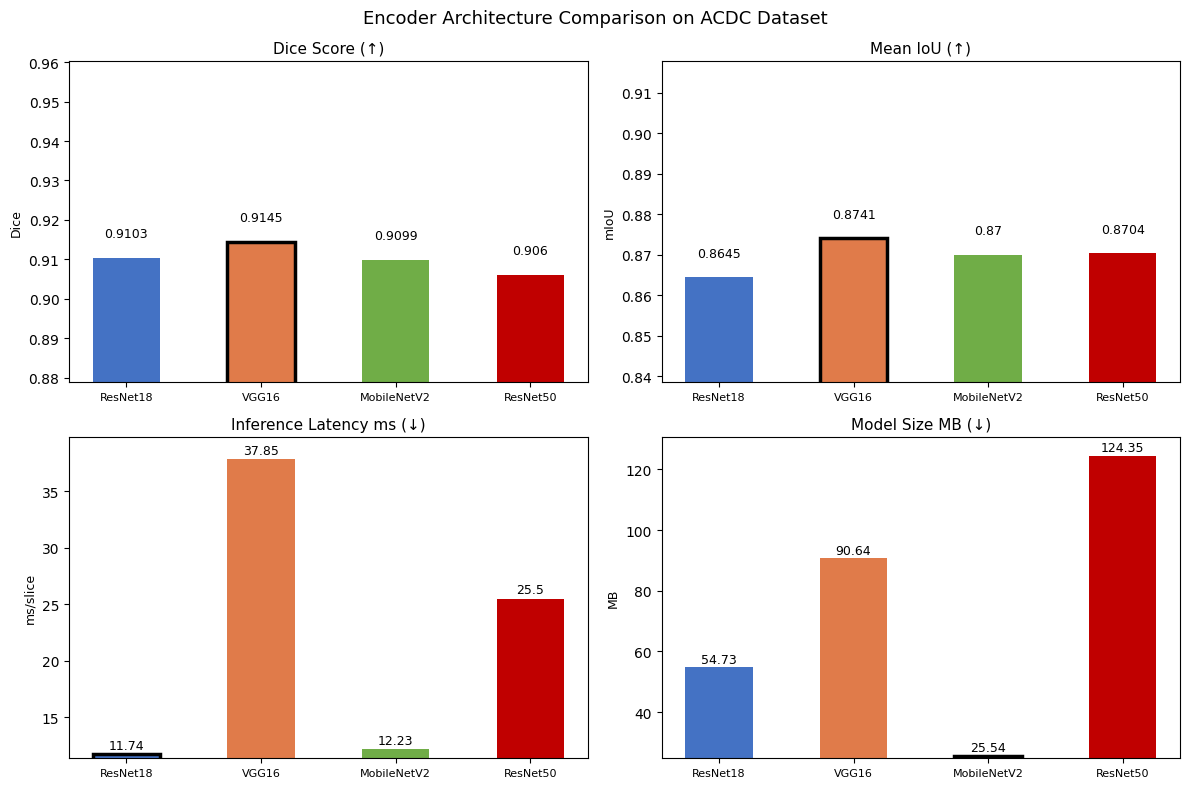

Saved


In [13]:
import matplotlib.pyplot as plt
import numpy as np

models = ["ResNet18", "VGG16", "MobileNetV2", "ResNet50"]
dice    = [0.9103, 0.9145, 0.9099, 0.9060]
miou    = [0.8645, 0.8741, 0.8700, 0.8704]
latency = [11.74, 37.85, 12.23, 25.50]
size    = [54.73, 90.64, 25.54, 124.35]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Encoder Architecture Comparison on ACDC Dataset", fontsize=13)

metrics = [
    (dice,    "Dice Score (↑)",          "Dice",     True),
    (miou,    "Mean IoU (↑)",            "mIoU",     True),
    (latency, "Inference Latency ms (↓)","ms/slice", False),
    (size,    "Model Size MB (↓)",       "MB",       False),
]

bar_color = ["#4472C4", "#E07B4A", "#70AD47", "#C00000"]  # blue, orange, green, red
best_edge = "black"

for idx, (vals, title, ylabel, higher_better) in enumerate(metrics):
    ax = axes[idx//2][idx%2]
    best = vals.index(max(vals)) if higher_better else vals.index(min(vals))
    
    bars = ax.bar(models, vals, color=bar_color, width=0.5)
    bars[best].set_edgecolor(best_edge)
    bars[best].set_linewidth(2.5)
    
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.005,
                f"{val}", ha="center", va="bottom", fontsize=9)
    
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_ylim(min(vals)*0.97, max(vals)*1.05)
    ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig("fig1_updated.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved")

Seed set to 42


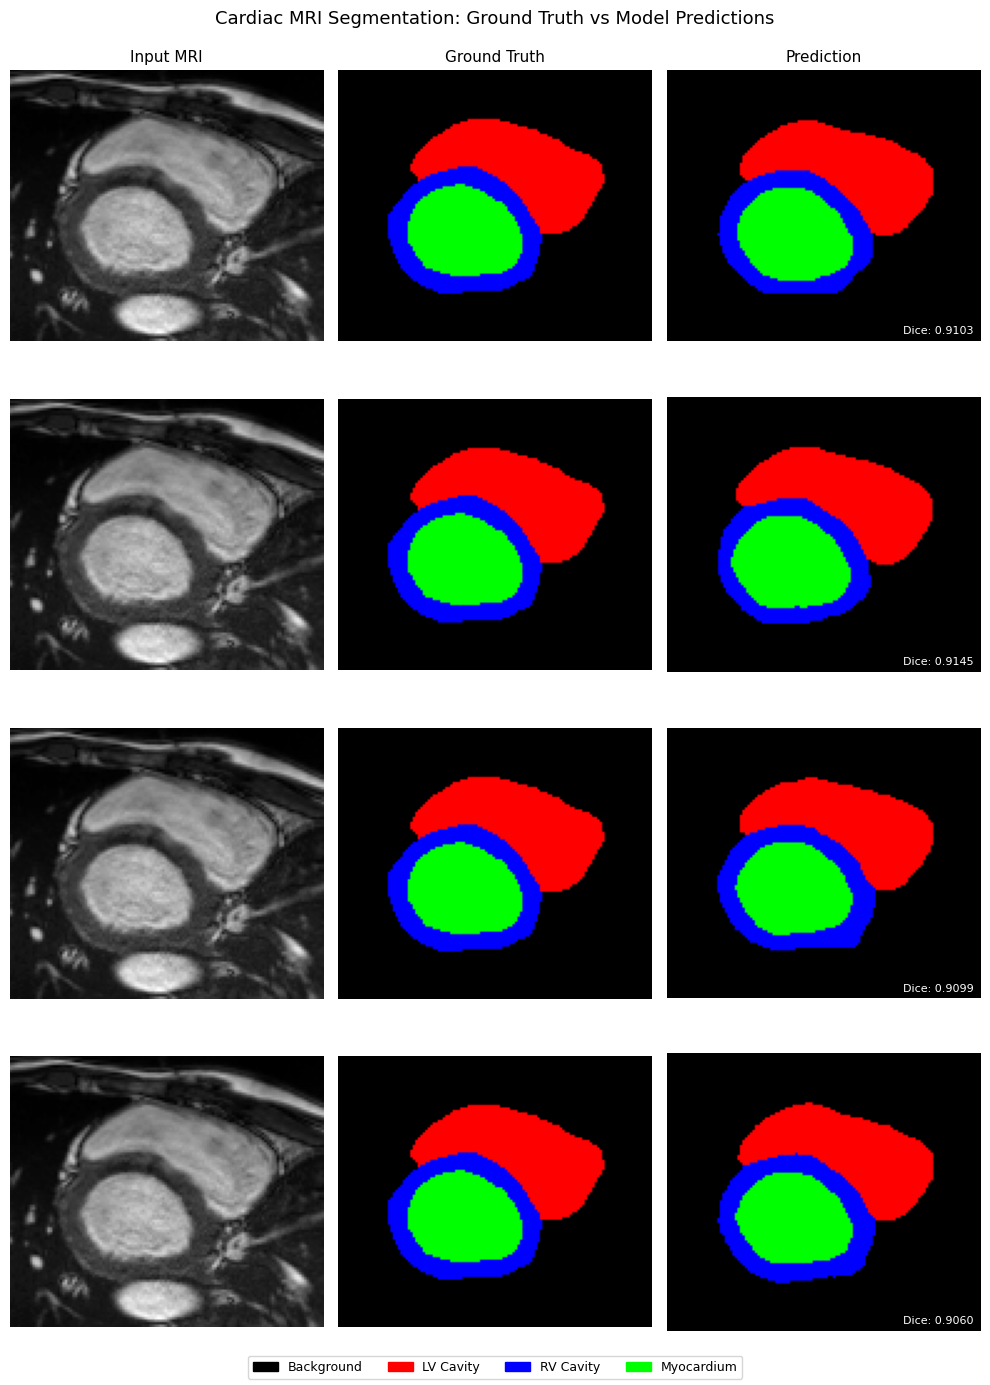

Saved


In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch

COLORS = {0: [0,0,0], 1: [255,0,0], 2: [0,0,255], 3: [0,255,0]}
LABELS = {0: "Background", 1: "LV Cavity", 2: "RV Cavity", 3: "Myocardium"}
DICE_MEANS = {
    "resnet18": 0.9103,
    "vgg16": 0.9145,
    "mobilenet_v2": 0.9099,
    "resnet50": 0.9060,
}

def mask_to_rgb(mask):
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for cls, color in COLORS.items():
        rgb[mask == cls] = color
    return rgb

def tight_crop(img, mask, pad=20):
    fg = mask > 0
    rows, cols = np.where(fg)
    if len(rows) == 0:
        return img, mask
    r1, r2 = max(0, rows.min()-pad), min(img.shape[0], rows.max()+pad)
    c1, c2 = max(0, cols.min()-pad), min(img.shape[1], cols.max()+pad)
    return img[r1:r2, c1:c2], mask[r1:r2, c1:c2]

# find best slice
pl.seed_everything(42, workers=True)
dm = ACDC2DDataModule(acdc_root, batch_size=1, num_workers=2, seed=42)
dm.setup()

best_idx = None
best_score = 0
for i in range(len(dm.test_ds)):
    _, mask = dm.test_ds[i]
    unique = torch.unique(mask).tolist()
    score = len([c for c in [1,2,3] if c in unique])
    if score > best_score:
        best_score = score
        best_idx = i
    if best_score == 3:
        break

fig, axes = plt.subplots(4, 3, figsize=(10, 14))
fig.suptitle("Cardiac MRI Segmentation: Ground Truth vs Model Predictions", fontsize=13)

col_labels = ["Input MRI", "Ground Truth", "Prediction"]
for col, label in enumerate(col_labels):
    axes[0][col].set_title(label, fontsize=11)

for row, encoder in enumerate(ENCODERS):
    ckpt_path = find_ckpt(FIXED_DIR, 42, encoder)
    model = LitUNet2D.load_from_checkpoint(ckpt_path, map_location="cpu")
    model = model.cuda().eval()

    img, mask = dm.test_ds[best_idx]
    with torch.no_grad():
        pred = torch.argmax(model(img.unsqueeze(0).cuda()), dim=1).squeeze().cpu().numpy()

    img_np = img.squeeze().numpy()
    mask_np = mask.numpy()

    img_crop, mask_crop = tight_crop(img_np, mask_np)
    _, pred_crop = tight_crop(img_np, pred)

    dice = DICE_MEANS[encoder]

    axes[row][0].imshow(img_crop, cmap="gray")
    axes[row][0].set_ylabel(encoder, fontsize=9)
    axes[row][0].axis("off")

    axes[row][1].imshow(mask_to_rgb(mask_crop))
    axes[row][1].axis("off")

    axes[row][2].imshow(mask_to_rgb(pred_crop))
    axes[row][2].text(0.98, 0.02, f"Dice: {dice:.4f}",
                      transform=axes[row][2].transAxes,
                      ha="right", va="bottom", fontsize=8, color="white")
    axes[row][2].axis("off")

patches = [mpatches.Patch(color=np.array(c)/255, label=l) for c, l in zip(COLORS.values(), LABELS.values())]
fig.legend(handles=patches, loc="lower center", ncol=4, fontsize=9)

plt.tight_layout()
plt.savefig("fig2_updated.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved")